[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/viscoelastic-startup/blob/main/notebooks/christov_2011_jordan_2010_nonrwa.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to verify with SymPy the lemmas on the Laplace transform of the velocity of a suddenly moved plate, $\mathcal{L}\{U'(t)\}$ with $U(t) = \widetilde U(t)H(t)$, and the Fourier&ndash;Laplace-domain solutions of [Christov (2011)](https://arxiv.org/abs/1107.2947) and [Jordan (2010)](https://doi.org/10.1016/j.nonrwa.2009.01.010). Furthermore, you will be able to regenerate Jordan's corrected solution of Stokes' first problem for a second-grade fluid in a porous half-space in its three forms, check it against a numerical inversion of the Laplace transform and a finite-difference solution, and see the erroneous solution it corrects fail.

The lesson of this pair of Comments is that not every disagreement with an initial condition is an error: here the disputed start-up jump is real, and it is the attempt to remove it, by replacing $\theta(t)$ with $1$ at the plate, that produces the wrong solution.

# PRELIMINARIES

This notebook uses [NumPy](https://numpy.org) ([Harris _et al._, 2020](https://doi.org/10.1038/s41586-020-2649-2)), [SciPy](https://scipy.org) ([Virtanen _et al._, 2020](https://doi.org/10.1038/s41592-019-0686-2)), [SymPy](https://www.sympy.org) ([Meurer _et al._, 2017](https://doi.org/10.7717/peerj-cs.103)), [Matplotlib](https://matplotlib.org) ([Hunter, 2007](https://doi.org/10.1109/MCSE.2007.55)) and [mpmath](https://mpmath.org) ([mpmath development team, 2023](https://mpmath.org/)).

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from IPython.display import HTML

# numerics
import numpy as np
from scipy.integrate import quad
from scipy.linalg import solve_banded
import mpmath as mp
import os

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version of this notebook written by [Ivan C. Christov](https://christov.tmnt-lab.org), Purdue University.

Reproducing results of I. C. Christov and P. M. Jordan.

# THE PROBLEM

Christov (2011) considers Stokes' first problem for an Oldroyd-B fluid, Eqs. (1)&ndash;(2) of the Comment,
\begin{align*}
    \frac{\partial u}{\partial t} + \lambda \frac{\partial^2 u}{\partial t^2} &= \nu\frac{\partial^2 u}{\partial y^2} + \nu\lambda_r\frac{\partial^3 u}{\partial y\partial t\partial y}, & y,t>0,\\
    u(0,t) &= U(t),\qquad u \to 0 \;\;\text{as}\;\; y\to\infty, & t>0,\\
    u(y,0) &= \frac{\partial u}{\partial t}(y,0) = 0, & y>0,
\end{align*}
where $U(t) := \widetilde U(t) H(t)$, with $H(t)$ the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function) and $\widetilde U(t)$ smooth. Jordan (2010) considers the second-grade special case ($\beta = 1$, $\lambda_1 = \lambda_2 = 0$) of the porous-half-space problem of Xue & Nie (2008), in their dimensionless variables $u^* = u/U_0$, $y^* = yU_0/\nu$, $t^* = tU_0^2/\nu$ (stars dropped), with $\tilde\lambda_3$ the dimensionless first normal-stress modulus and $\gamma$ the porous-medium parameter:
\begin{align*}
    \frac{\partial u}{\partial t} &= \left(1 + \tilde\lambda_3\frac{\partial}{\partial t}\right)\left(\frac{\partial^2 u}{\partial y^2} - \gamma^2 u\right), &\quad y, t > 0,\\
    u(0,t) &= \theta(t),\qquad u \to 0 \;\;\text{as}\;\; y\to\infty, & t>0,\\
    u(y,0) &= 0, & y>0,
\end{align*}
with $\theta(t)$ the Heaviside step function in Jordan's notation. Jordan (2010) has no figure; below $\tilde\lambda_3 = 1$, $\gamma = 0.5$, $t = 0.5$ and $2$.

The plate's velocity _might appear_ to be an arbitrary function of time at this point, but it is not: for the motion to be _sudden_, one must write $U(t) := \widetilde U(t)H(t)$, with $\widetilde U$ smooth. Since $H$ is discontinuous at $t = 0$, so is $U$, and $U(0)$ has no value to speak of, while $\widetilde U(0)$ has one. This is why the textbook rule $\mathcal{L}\{U^\prime\} = q\bar{U} - U(0)$ cannot be applied to $U$ as written: what holds is Lemma 3 below, $\mathcal{L}\{U^\prime\} = q\overline{\widetilde U}$, with no boundary term at all. This is _not_ a new boundary condition; it is the mathematically precise statement of the same suddenly moved plate. (Prof. Arthur Mattuck's MIT 18.03 lecture on [discontinuous inputs](https://ocw.mit.edu/courses/18-03-differential-equations-spring-2010/resources/lecture-22-using-laplace-transform-to-solve-odes-with-discontinuous-inputs/) is a gentle introduction to transforming such functions.)

The Lemmas of Christov (2011): with $\delta(t)$ the [Dirac delta](https://en.wikipedia.org/wiki/Dirac_delta_function),

**Lemma 1.** $U'(t) = \widetilde U'(t)H(t) + \widetilde U(0)\delta(t)$.

**Lemma 2.** $\mathcal{L}\left\{\widetilde U'(t)H(t)\right\}(q) = q\overline{\widetilde U}(q) - \widetilde U(0)$.

**Lemma 3.** $\mathcal{L}\left\{U'(t)\right\}(q) = q\overline{\widetilde U}(q)$.

The next cell checks Lemmas 1 and 2 for a general $\widetilde U$, and Lemma 3 for $\widetilde U = 1$, $\cos\omega t$, $\sin\omega t$, $t$. It also shows two incorrect shortcuts: the rule $\mathcal{L}\{U'\} = q\overline{U} - U(0)$ with $U(0) = 0$ (used by Fetecau _et al._ (2011), [doi:10.1016/j.nonrwa.2009.12.009](https://doi.org/10.1016/j.nonrwa.2009.12.009)), which gives the right answer by accident, and $U' = 0$ for a constant plate velocity (used by Xue & Nie (2008)), which does not.

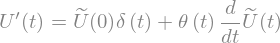

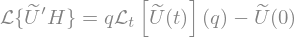

Lemma 3: L{U'} - q L{U~}; Fetecau et al. shortcut - q L{U~}; U' = 0 shortcut - q L{U~}
  U~ = 1           : 0, 0, -1
  U~ = cos(omega*t): 0, 0, -1
  U~ = sin(omega*t): 0, 0, 0
  U~ = t           : 0, 0, 0


In [2]:
# Lemmas 1-3 of Christov (2011)
t = sp.Symbol('t', real=True)   # not positive=True, otherwise SymPy sets DiracDelta(t) = 0
q, omega = sp.symbols('q omega', positive=True)
Ut = sp.Function(r'\widetilde{U}')

lemma1 = sp.diff(Ut(t)*sp.Heaviside(t), t)
display(sp.Eq(sp.Symbol("U'(t)"), lemma1.subs(Ut(t)*sp.DiracDelta(t), Ut(0)*sp.DiracDelta(t))))
display(sp.Eq(sp.Symbol(r"\mathcal{L}\{\widetilde{U}'H\}"), sp.laplace_transform(sp.diff(Ut(t), t)*sp.Heaviside(t), t, q, noconds=True)))

print('Lemma 3: L{U\'} - q L{U~}; Fetecau et al. shortcut - q L{U~}; U\' = 0 shortcut - q L{U~}')
for U_tilde in [sp.Integer(1), sp.cos(omega*t), sp.sin(omega*t), t]:
    L_U_tilde = sp.laplace_transform(U_tilde, t, q, noconds=True)
    L_derivative = sp.laplace_transform(sp.diff(U_tilde*sp.Heaviside(t), t), t, q, noconds=True)
    shortcut_fetecau = q*L_U_tilde - 0                  # L{U'} = q L{U} - U(0), with U(0) set to 0
    shortcut_zero = sp.laplace_transform(sp.diff(U_tilde, t), t, q, noconds=True)   # the jump ignored
    print(f'  U~ = {str(U_tilde):12s}: {sp.simplify(L_derivative - q*L_U_tilde)}, '
          f'{sp.simplify(shortcut_fetecau - q*L_U_tilde)}, {sp.simplify(shortcut_zero - q*L_U_tilde)}')

In [3]:
# Generic helpers, used by the erroneous solution below and by the correct one
def sine_integral(g, y, t, lam3, gamma):
    """Integral of g(zeta, t, lam3, gamma)*sin(zeta*y) over 0 < zeta < infinity."""
    # ordinary quadrature on (0, 1), then a Fourier-weighted rule for the slowly decaying tail
    head = quad(lambda zeta: g(zeta, t, lam3, gamma)*np.sin(zeta*y), 0, 1, limit=200)[0]
    tail = quad(g, 1, np.inf, args=(t, lam3, gamma), weight='sin', wvar=y, limlst=200)[0]
    return head + tail

def decay(zeta, t, lam3, gamma):
    """exp(-(zeta^2 + gamma^2) t/(1 + lam3 zeta^2 + lam3 gamma^2))."""
    return np.exp(-(zeta**2 + gamma**2)*t/(1 + lam3*zeta**2 + lam3*gamma**2))

def g_growth(zeta, t, lam3, gamma):
    """zeta/(zeta^2 + gamma^2) [1 - exp(...)], the integrand of Eq. (54) of Xue & Nie and of the first integral of Eq. (7) of Jordan."""
    return zeta/(zeta**2 + gamma**2)*(1 - decay(zeta, t, lam3, gamma))

# THE ERRONEOUS SOLUTION

> &#x26A0;&#xFE0F; **ERRONEOUS SOLUTION, reproduced as printed** in Eq. (54) of Xue & Nie (2008) ([doi:10.1016/j.nonrwa.2007.04.007](https://doi.org/10.1016/j.nonrwa.2007.04.007)), p. 1635, the second-grade special case of their solution, obtained with the boundary condition $u(0,t) = 1$ in place of $u(0,t) = \theta(t)$ (Jordan, 2010). It is shown below to be wrong.

$$
    U(y,t) = \frac{2}{\pi}\int_0^\infty\frac{\zeta\sin(\zeta y)}{\zeta^2+\gamma^2}\left[1 - \exp\left(-\frac{\zeta^2+\gamma^2}{1+\lambda_3\zeta^2+\lambda_3\gamma^2}t\right)\right]\mathrm{d}\zeta,
$$
where their $\lambda_3$ is $\tilde\lambda_3$.

In [4]:
# WRONG, as printed: Eq. (54) of Xue & Nie (2008)
def wrong_xue_nie_54(y, t, lam3, gamma):
    """Erroneous solution, as printed: Eq. (54) of Xue & Nie (2008)."""
    if y == 0:
        return 0.0   # sin(0) = 0: the formula gives 0 at the plate
    return 2/np.pi*sine_integral(g_growth, y, t, lam3, gamma)

> &#x26A0;&#xFE0F; **END OF THE ERRONEOUS SOLUTION.** The cells below are correct.

# THE CORRECT SOLUTION

With Lemma 3, the Fourier sine transform (with the factor $\sqrt{2/\pi}$) and the [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform) of the Oldroyd-B problem give Eq. (5) of Christov (2011), with $\alpha = \nu\lambda_r$,
$$
    \overline{u_\mathrm{s}}(\xi,q) = \xi\sqrt{\frac{2}{\pi}}\frac{\nu + \alpha q}{\lambda q^2 + (1 + \alpha \xi^2) q + \nu\xi^2}\overline{\widetilde U}(q),
$$
and, for Jordan's problem (the transform $\int_0^\infty u\sin(\zeta y)\,\mathrm{d}y$, $\theta(t)$ at the plate), Eq. (6) of Jordan (2010),
$$
    \bar{U}(\zeta,s) = \frac{\zeta}{s[s(1+\tilde\lambda_3\gamma^2+\tilde\lambda_3\zeta^2)+\zeta^2+\gamma^2]} + \frac{\tilde\lambda_3\zeta}{s(1+\tilde\lambda_3\gamma^2+\tilde\lambda_3\zeta^2)+\zeta^2+\gamma^2},
$$
whose second quotient is missing from Xue & Nie's Eq. (34) at $\beta = 1$, $\lambda_1 = \lambda_2 = 0$. The next cell derives both with SymPy; it should print Eq. (5), then $0$ for the difference from Eq. (6), then the transform without the $\delta(t)$ term (the first quotient only).

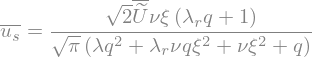

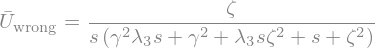

In [5]:
# Eq. (5) of Christov (2011) and Eq. (6) of Jordan (2010), in the Fourier-Laplace domain
xi, zeta, s, nu, lam, lam_r, lam3, gamma = sp.symbols('xi zeta s nu lambda lambda_r lambda3 gamma', positive=True)
w = sp.Function('w')
W, w0, w1 = sp.symbols(r'\overline{u_s} w_0 w_1')

def laplace(expr, variable):
    """Laplace transform in t to the given variable, with W, w(0), w'(0) as symbols."""
    L = sp.laplace_transform(expr, t, variable, noconds=True)
    L = L.subs(sp.LaplaceTransform(w(t), t, variable), W)
    L = L.subs(sp.Subs(sp.Derivative(w(t), t), t, 0), w1).subs(w(0), w0)
    L = L.subs(sp.LaplaceTransform(Ut(t), t, variable), sp.Symbol(r'\overline{\widetilde{U}}'))
    return sp.expand(L)

# Christov (2011): sqrt(2/pi) sine transform; the transform of d^2u/dy^2 is -xi^2 w + xi sqrt(2/pi) U(t)
plate = Ut(t)*sp.Heaviside(t)
lhs = w(t).diff(t) + lam*w(t).diff(t, 2)
rhs = nu*(-xi**2*w(t) + xi*sp.sqrt(2/sp.pi)*plate) + nu*lam_r*sp.diff(-xi**2*w(t) + xi*sp.sqrt(2/sp.pi)*plate, t)
eq5 = sp.solve(laplace(lhs - rhs, q).subs({w0: 0, w1: 0}), W)[0]
display(sp.Eq(W, sp.factor(eq5)))

# Jordan (2010): theta(t) at the plate; the transform of d^2u/dy^2 is -zeta^2 w + zeta theta(t)
theta = sp.Heaviside(t)
operator_correct = (-zeta**2*w(t) + zeta*theta - gamma**2*w(t)) + lam3*sp.diff(-zeta**2*w(t) + zeta*theta - gamma**2*w(t), t)
operator_wrong = (-zeta**2*w(t) + zeta*theta - gamma**2*w(t)) + lam3*sp.diff(-zeta**2*w(t) - gamma**2*w(t), t)
W_correct = sp.solve(laplace(operator_correct - w(t).diff(t), s).subs(w0, 0), W)[0]
W_wrong = sp.solve(laplace(operator_wrong - w(t).diff(t), s).subs(w0, 0), W)[0]
D = s*(1 + lam3*gamma**2 + lam3*zeta**2) + zeta**2 + gamma**2
eq6 = zeta/(s*D) + lam3*zeta/D
display(sp.simplify(W_correct - eq6))
display(sp.Eq(sp.Symbol(r'\bar{U}_\mathrm{wrong}'), sp.factor(W_wrong)))

Inverting Eq. (6) gives Eq. (7) of Jordan (2010),
$$
    u(y,t) = \theta(t)\left\{\frac{2}{\pi}\int_0^\infty\frac{\zeta\sin(\zeta y)}{\zeta^2+\gamma^2}\left[1 - \exp\left(\frac{-(\zeta^2+\gamma^2)t}{1+\tilde\lambda_3\zeta^2+\tilde\lambda_3\gamma^2}\right)\right]\mathrm{d}\zeta + \frac{2\tilde\lambda_3}{\pi}\int_0^\infty\frac{\zeta\sin(\zeta y)}{1+\tilde\lambda_3\zeta^2+\tilde\lambda_3\gamma^2}\exp\left(\frac{-(\zeta^2+\gamma^2)t}{1+\tilde\lambda_3\zeta^2+\tilde\lambda_3\gamma^2}\right)\mathrm{d}\zeta\right\},
$$
which, using $(2/\pi)\int_0^\infty \zeta\sin(\zeta y)/(\zeta^2+\gamma^2)\,\mathrm{d}\zeta = \mathrm{e}^{-\gamma y}$, simplifies to Eq. (8),
$$
    u(y,t) = \theta(t)\left\{\exp(-\gamma y) - \frac{2}{\pi}\int_0^\infty\frac{\zeta\sin(\zeta y)}{\zeta^2+\gamma^2}\exp\left(\frac{-(\zeta^2+\gamma^2)t}{1+\tilde\lambda_3\zeta^2+\tilde\lambda_3\gamma^2}\right)\mathrm{d}\zeta + \frac{2\tilde\lambda_3}{\pi}\int_0^\infty\frac{\zeta\sin(\zeta y)}{1+\tilde\lambda_3\zeta^2+\tilde\lambda_3\gamma^2}\exp\left(\frac{-(\zeta^2+\gamma^2)t}{1+\tilde\lambda_3\zeta^2+\tilde\lambda_3\gamma^2}\right)\mathrm{d}\zeta\right\}.
$$
With, Eq. (9), $Y = y$, $T = t/(1+\tilde\lambda_3\gamma^2)$, $l^2 = \tilde\lambda_3/(1+\tilde\lambda_3\gamma^2)$, $b = \gamma$, $\eta = (\zeta^2+b^2)/(1+l^2\zeta^2)$, Eq. (8) becomes Eq. (10),
$$
    u(Y,T) = \theta(T)\left[\mathrm{e}^{-bY} - \frac{1}{\pi}\int_{b^2}^{l^{-2}}\mathrm{e}^{-\eta T}\sin\left(\frac{Y}{l}\sqrt{\frac{\eta-b^2}{l^{-2}-\eta}}\right)\frac{\mathrm{d}\eta}{\eta}\right]\qquad (bl<1).
$$
The next cell checks with SymPy that the Laplace transforms of the two terms of Eq. (7) are the two quotients of Eq. (6), and that the substitution of Eq. (9) turns the sine argument and the exponent of Eq. (10) into those of Eq. (8); it should print four zeros.

In [6]:
# Eqs. (6)-(10) of Jordan (2010)
a = (zeta**2 + gamma**2)/(1 + lam3*zeta**2 + lam3*gamma**2)
term1 = zeta/(zeta**2 + gamma**2)*(1 - sp.exp(-a*t))
term2 = lam3*zeta/(1 + lam3*zeta**2 + lam3*gamma**2)*sp.exp(-a*t)
display(sp.simplify(sp.laplace_transform(term1, t, s, noconds=True) - zeta/(s*D)))
display(sp.simplify(sp.laplace_transform(term2, t, s, noconds=True) - lam3*zeta/D))
b = gamma
l2 = lam3/(1 + lam3*gamma**2)
eta = (zeta**2 + b**2)/(1 + l2*zeta**2)
Y, T = sp.symbols('Y T', positive=True)
display(sp.simplify(sp.sqrt(l2)**-1*sp.sqrt((eta - b**2)/(1/l2 - eta)) - zeta))
display(sp.simplify(eta*t/(1 + lam3*gamma**2) - a*t))

In [7]:
# Eqs. (7), (8), (10) of Jordan (2010): correct solution in three forms
def g_decay(zeta, t, lam3, gamma):
    """zeta/(zeta^2 + gamma^2) exp(...)."""
    return zeta/(zeta**2 + gamma**2)*decay(zeta, t, lam3, gamma)

def g_jump(zeta, t, lam3, gamma):
    """zeta/(1 + lam3 zeta^2 + lam3 gamma^2) exp(...), the integrand carrying the start-up jump."""
    return zeta/(1 + lam3*zeta**2 + lam3*gamma**2)*decay(zeta, t, lam3, gamma)

def jordan_7(y, t, lam3, gamma):
    """Eq. (7) of Jordan (2010), at one point y > 0."""
    return 2/np.pi*sine_integral(g_growth, y, t, lam3, gamma) + 2*lam3/np.pi*sine_integral(g_jump, y, t, lam3, gamma)

def unsteadyv(y, t, lam3, gamma):
    """Correct solution, Eq. (8) of Jordan (2010)."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    return (np.exp(-gamma*y) - 2/np.pi*sine_integral(g_decay, y, t, lam3, gamma)
            + 2*lam3/np.pi*sine_integral(g_jump, y, t, lam3, gamma))

def jordan_10(y, t, lam3, gamma):
    """Eq. (10) of Jordan (2010), with the variables of Eq. (9), at one point y > 0."""
    T = t/(1 + lam3*gamma**2)
    l = np.sqrt(lam3/(1 + lam3*gamma**2))
    b = gamma
    integral = quad(lambda eta: np.exp(-eta*T)*np.sin(y/l*np.sqrt((eta - b**2)/(1/l**2 - eta)))/eta,
                    b**2, 1/l**2, limit=5000)[0]   # the integrand oscillates without bound as eta -> 1/l^2
    return np.exp(-b*y) - integral/np.pi

def profile(func, y, t, lam3, gamma):
    """Evaluate a point-wise solution func(y, t, lam3, gamma) on an array of y."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = func(y[j], t, lam3, gamma)
    return u

The second integral of Eq. (7), the one carrying $\tilde\lambda_3$, is the start-up jump: at $t = 0^+$ the exponentials are $1$, the first two terms of Eq. (8) cancel, and this integral alone survives, so that $u(y,0^+) = \lim_{s\to\infty}s\bar{u}(y,s) \ne 0$. Xue & Nie (2008) read such a jump as a failure to satisfy the initial condition, and imposed $u(0,t) = 1$ in place of $u(0,t) = \theta(t)$ to be rid of it. As Jordan (2010) points out, the initial condition $u(y,0) = 0$ is an abbreviated way of writing $\lim_{t\to0^-}u(y,t) = 0$, the state _prior_ to start-up, which the jump does not violate: it is physically consistent with the viscoelastic nature of the fluid, whose mixed derivative answers the plate at once.

# AN INDEPENDENT CHECK

Two independent checks. First, the Laplace transform in $t$ of Jordan's problem gives
$$
    \bar{u}(y,s) = \frac{1}{s}\exp\left(-y\sqrt{\gamma^2 + \frac{s}{1+\tilde\lambda_3 s}}\right),
$$
inverted numerically by the algorithm of [de Hoog _et al._ (1982)](https://doi.org/10.1137/0903022) in [mpmath's `invertlaplace`](https://mpmath.org/doc/current/calculus/inverselaplace.html). Second, the finite-difference scheme of Eqs. (4)&ndash;(5) of [I. C. Christov & C. I. Christov (2010)](https://arxiv.org/abs/1003.2188) with $\partial^2/\partial y^2$ replaced by $\partial^2/\partial y^2 - \gamma^2$, with $\nu = 1$, $\alpha = \tilde\lambda_3$, $M = 5000$, $K = 1000$, $L = 20$.

In [8]:
# Laplace-domain solution of Jordan's problem, inverted by de Hoog's algorithm
def ubar_mp(s, y, lam3, gamma):
    """Laplace-domain solution in mpmath arithmetic."""
    return mp.exp(-y*mp.sqrt(gamma**2 + s/(1 + lam3*s)))/s

def dehoog_inverse(y, t, lam3, gamma):
    """Laplace-domain solution inverted by mpmath's de Hoog algorithm, point by point in y."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = float(mp.invertlaplace(lambda s: ubar_mp(s, y[j], lam3, gamma), t, method='dehoog'))
    return u

In [9]:
# Eqs. (4)-(5) of I. C. Christov & C. I. Christov (2010): finite-difference scheme, here with the porous-medium term
def sg_fd(nu, alpha, tf, L=20.0, M=5000, K=1000, ramp_time=0.0, v00=0.0, oscillation='', omega=0.0, gamma=0.0):
    """Scheme of Eq. (4) with the boundary conditions of Eq. (5) of I. C. Christov & C. I. Christov (2010), V0 = 1."""
    # ramp_time > 0 moves the plate with 1 - exp(-t/ramp_time) instead of 1; oscillation = 'cos' or 'sin'
    # moves it with cos(omega t) or sin(omega t); v00 is the plate velocity at n = 0;
    # gamma > 0 adds the porous-medium term, d^2/dy^2 -> d^2/dy^2 - gamma^2
    dy = L/(M - 1)
    dt = tf/(K - 1)
    y = np.linspace(0, L, M)
    v = np.zeros(M)
    v[0] = v00
    a = alpha/dy**2
    b = nu*dt/(2*dy**2)
    # tridiagonal matrix of (1 - (alpha + nu dt/2) delta^2/dy^2) acting on the interior points
    ab = np.zeros((3, M-2))
    ab[0, 1:] = -(a + b)
    ab[1, :] = 1 + 2*(a + b) + (alpha + nu*dt/2)*gamma**2
    ab[2, :-1] = -(a + b)
    for n in range(1, K):
        if ramp_time > 0:
            plate = 1 - np.exp(-n*dt/ramp_time)
        elif oscillation == 'cos':
            plate = np.cos(omega*n*dt)
        elif oscillation == 'sin':
            plate = np.sin(omega*n*dt)
        else:
            plate = 1.0
        rhs = v[1:-1] - (a - b)*(v[2:] - 2*v[1:-1] + v[:-2]) + (alpha - nu*dt/2)*gamma**2*v[1:-1]
        rhs[0] = rhs[0] + (a + b)*plate
        v_new = np.zeros(M)
        v_new[0] = plate
        v_new[1:-1] = solve_banded((1, 1), ab, rhs)
        v = v_new
    return y, v

The next cell prints the checks, with $\tilde\lambda_3 = 1$ and $\gamma = 0.5$:

* the limit $\gamma = 0$, where Eq. (8) is the second-grade solution of Stokes' first problem (Eq. (3) of I. C. Christov & C. I. Christov (2010) with $\nu = 1$, $\alpha = \tilde\lambda_3$), compared through de Hoog's inversion (at the quadrature tolerance);
* at $t = 0.5$ and $2$: Eq. (8) against de Hoog's inversion (about $10^{-10}$), Eq. (7) against Eq. (8), Eq. (10) against de Hoog, and the scheme; the error of Eq. (54) of Xue & Nie (2008);
* the convergence of the scheme as $M$ and $K$ are doubled (formally $O[(\Delta t)^2 + (\Delta y)^2]$, but first order in practice, because of the start-up jump).

Where a convergence table prints a number in parentheses, it is the estimated order of convergence, $\log_2$ of the ratio of successive errors.

In [10]:
# Checks for Christov (2011) and Jordan (2010)
lam3, gamma = 1.0, 0.5
print('LIMIT gamma = 0 (should be at the quadrature tolerance)')
y_limit = np.array([0.2, 0.5, 1.0])
print(f'  max|Eq. (8) at gamma = 0 - de Hoog| = {np.abs(profile(unsteadyv, y_limit, 0.5, lam3, 0.0) - dehoog_inverse(y_limit, 0.5, lam3, 0.0)).max():.1e}')

y = np.linspace(0.05, 6, 25)
for t in [0.5, 2.0]:
    print(f'\nt = {t}, max over 0.05 <= y <= 6')
    u_dehoog = dehoog_inverse(y, t, lam3, gamma)
    u_8 = profile(unsteadyv, y, t, lam3, gamma)
    print(f'  Eq. (8) vs de Hoog: {np.abs(u_8 - u_dehoog).max():.1e}')
    assert np.abs(u_8 - u_dehoog).max() < 1e-6   # a regression guard: the notebook stops here if a future edit breaks the agreement
    print(f'  Eq. (7) vs Eq. (8): {np.abs(profile(jordan_7, y, t, lam3, gamma) - u_8).max():.1e}')
    print(f'  Eq. (10) vs de Hoog: {np.abs(profile(jordan_10, y, t, lam3, gamma) - u_dehoog).max():.1e}')
    print(f'  erroneous Eq. (54) of Xue & Nie - Eq. (8): {np.abs(profile(wrong_xue_nie_54, y, t, lam3, gamma) - u_8).max():.2f}')
    print('  convergence of the scheme versus de Hoog:')
    print('    grid: max error (estimated order of convergence)')
    # the estimated order of convergence is log2 of the ratio of successive errors, since the grid is halved
    previous = None
    for M, K in [(2500, 500), (5000, 1000), (10000, 2000)]:
        y_fd, u_fd = sg_fd(1.0, lam3, t, M=M, K=K, gamma=gamma)
        error = np.abs(np.interp(y, y_fd, u_fd) - u_dehoog).max()
        if previous is None:
            print(f'    M = {M:5d}, K = {K:4d}: {error:.1e}')
        else:
            print(f'    M = {M:5d}, K = {K:4d}: {error:.1e} ({np.log2(previous/error):.2f})')
        previous = error

LIMIT gamma = 0 (should be at the quadrature tolerance)
  max|Eq. (8) at gamma = 0 - de Hoog| = 7.2e-13

t = 0.5, max over 0.05 <= y <= 6
  Eq. (8) vs de Hoog: 5.3e-11
  Eq. (7) vs Eq. (8): 7.2e-11


  Eq. (10) vs de Hoog: 4.7e-09
  erroneous Eq. (54) of Xue & Nie - Eq. (8): 0.58
  convergence of the scheme versus de Hoog:
    grid: max error (estimated order of convergence)
    M =  2500, K =  500: 5.3e-05
    M =  5000, K = 1000: 2.7e-05 (0.99)


    M = 10000, K = 2000: 1.4e-05 (0.98)

t = 2.0, max over 0.05 <= y <= 6


  Eq. (8) vs de Hoog: 2.3e-11
  Eq. (7) vs Eq. (8): 5.1e-11


  Eq. (10) vs de Hoog: 9.4e-09
  erroneous Eq. (54) of Xue & Nie - Eq. (8): 0.14
  convergence of the scheme versus de Hoog:
    grid: max error (estimated order of convergence)
    M =  2500, K =  500: 1.0e-04
    M =  5000, K = 1000: 5.0e-05 (1.00)


    M = 10000, K = 2000: 2.5e-05 (0.99)


# A FIGURE NEITHER PAPER HAS

Jordan (2010) has no figure; this one is new. It shows $u$ versus $y$ for $\tilde\lambda_3 = 1$, $\gamma = 0.5$ at $t = 0.5$ and $2$: Eq. (8) of Jordan (2010) (solid), the finite-difference solution (dots) and the erroneous Eq. (54) of Xue & Nie (2008) (dashed).

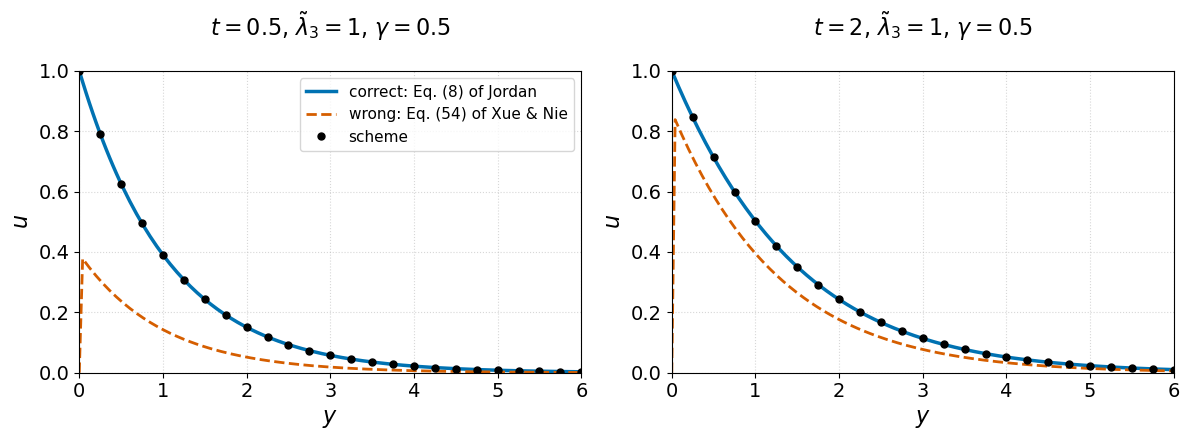

In [11]:
# New figure: Eq. (8) of Jordan (2010) against finite differences and Eq. (54) of Xue & Nie (2008)
lam3, gamma = 1.0, 0.5
times = [0.5, 2.0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), tight_layout=True)
for k in range(2):
    t = times[k]
    ax = axes[k]
    y = np.linspace(0, 6, 150)
    y_fd, u_fd = sg_fd(1.0, lam3, t, gamma=gamma)
    y_dots = np.linspace(0, 6, 25)
    ax.plot(y, profile(unsteadyv, y, t, lam3, gamma), color='#0072B2', linewidth=2.5, label='correct: Eq. (8) of Jordan')
    ax.plot(y, profile(wrong_xue_nie_54, y, t, lam3, gamma), color='#D55E00', linewidth=2, linestyle='dashed',
            label='wrong: Eq. (54) of Xue & Nie')
    ax.plot(y_dots, np.interp(y_dots, y_fd, u_fd), 'o', color='black', markersize=5, label='scheme')
    ax.set_xlabel('$y$')
    ax.set_ylabel('$u$')
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 1)
    ax.set_title(rf'$t = {t:g}$, $\tilde\lambda_3 = {lam3:g}$, $\gamma = {gamma:g}$')
    ax.grid(alpha=0.5, linestyle='dotted')
axes[0].legend(loc='upper right', fontsize=11)
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/christov_2011_jordan_2010_new.png', dpi=200, bbox_inches='tight')

# EXPLORE IT YOURSELF

In [12]:
# Eq. (8) of Jordan (2010) and Eq. (54) of Xue & Nie (2008): plot function
def plot_func(lam3, gamma, t):
    y = np.linspace(0, 6, 101)         # fine grid for the envelope
    y_arrows = np.linspace(0, 6, 16)   # about 15 arrows, one at the wall
    u = profile(unsteadyv, y, t, lam3, gamma)
    u_wrong = profile(wrong_xue_nie_54, y, t, lam3, gamma)

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel('$y$')
    ax.set_ylim(0, 6)
    ax.set_xlabel('$u$')
    ax.set_xlim(0, 1.1)
    ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label=f'correct, $t={t:.2f}$')
    ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
    ax.plot(u_wrong, y, color='#D55E00', linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (54)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.5, linestyle='dotted')
    plt.show()

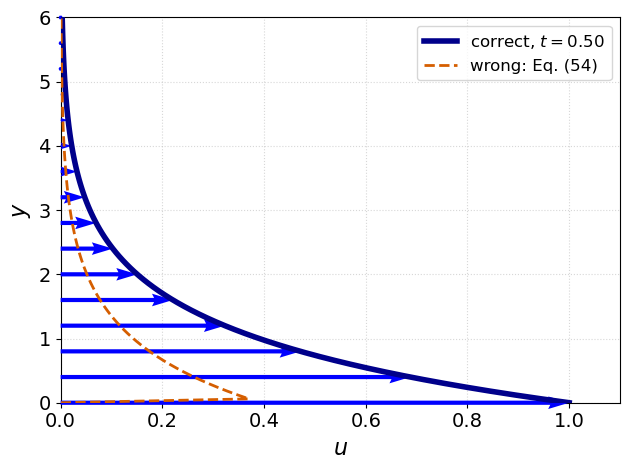

In [13]:
# Eq. (8) of Jordan (2010) and Eq. (54) of Xue & Nie (2008): static plot (the interactive widget below is stripped in the GitHub preview)
plot_func(1.0, 0.5, 0.5)

In [14]:
# Eq. (8) of Jordan (2010) and Eq. (54) of Xue & Nie (2008): interactive plot
interact(plot_func,
         lam3=widgets.FloatSlider(value=1.0, min=0.05, max=3, step=0.05, description='SG param., λ3'),
         gamma=widgets.FloatSlider(value=0.5, min=0.0, max=2, step=0.05, description='Porous, γ'),
         t=widgets.FloatSlider(value=0.5, min=0.02, max=5, step=0.02, description='Time, t'));

In [15]:
# Eq. (8) of Jordan (2010) and Eq. (54) of Xue & Nie (2008): animation
lam3, gamma = 1.0, 0.5
# number of animation frames, and the time of the first one, as `animate' computes it below
numframes = 40
tmax = 4.0
# the first frame; the time steps as the square of the counter
t0 = tmax/numframes**2
y = np.linspace(0, 6, 101)         # fine grid for the envelope
y_arrows = np.linspace(0, 6, 16)   # about 15 arrows, one at the wall
u = profile(unsteadyv, y, t0, lam3, gamma)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$y$')
ax.set_ylim(0, 6)
ax.set_xlabel('$u$')
ax.set_xlim(0, 1.1)
ax.grid(alpha=0.5, linestyle='dotted')
plt.close()

line, = ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label='correct')
line_wrong, = ax.plot(profile(wrong_xue_nie_54, y, t0, lam3, gamma), y, color='#D55E00',
                      linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (54)')
quiv = ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
ax.legend(loc='upper right')

# animation function called sequentially by `FuncAnimation' below
def animate(i):
    # the i passed is the frame counter; squaring it keeps the front, which spreads like
    # sqrt(t), moving evenly and puts frames at the early times, where the start-up jump is
    tstar = ((i + 1)/numframes)**2*tmax
    u = profile(unsteadyv, y, tstar, lam3, gamma)
    line.set_data(u, y)
    line_wrong.set_data(profile(wrong_xue_nie_54, y, tstar, lam3, gamma), y)
    quiv.set_UVC(np.interp(y_arrows, y, u), 0*y_arrows)
    line.set_label(f'correct, $t={tstar:.3g}$')
    legend = ax.legend(loc='upper right')
    return (line, line_wrong, quiv, legend)

anim = animation.FuncAnimation(fig, animate, frames=numframes, interval=150, blit=True, repeat=False)

In [16]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [17]:
# To save the animation, use something like
# anim.save('christov_2011_jordan_2010.mp4')

# WHAT PROBLEM DOES THE WRONG SOLUTION ACTUALLY SOLVE?

The transform without the $\delta(t)$ term is Eq. (6) divided by $1 + \tilde\lambda_3 s$, so Eq. (54) of Xue & Nie (2008) solves Jordan's problem with the plate ramped on the retardation timescale (that is, $\tilde\lambda_3$),
$$
    u(0,t) = \left(1 - \mathrm{e}^{-t/\tilde\lambda_3}\right)\theta(t),\qquad \bar{u}_\mathrm{wrong}(y,s) = \frac{\bar{u}(y,s)}{1+\tilde\lambda_3 s}.
$$
This identification is shown here; it is not stated in Jordan (2010). It extends to this problem the ramped plate that [I. C. Christov & C. I. Christov (2010)](https://arxiv.org/abs/1003.2188) found for Stokes' first problem of a second-grade fluid. The next cell should print $1/(\lambda_3 s + 1)$, then compare Eq. (54) with the de Hoog inversion of $\bar{u}/(1+\tilde\lambda_3 s)$ (at the quadrature tolerance).

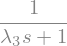

max|Eq. (54) of Xue & Nie - ramped-plate solution| = 4.4e-11


In [18]:
# Eq. (54) of Xue & Nie (2008) versus the ramped-plate solution, inverse of ubar/(1 + lam3 s)
display(sp.simplify(W_wrong/W_correct))
lam3, gamma = 1.0, 0.5
y = np.linspace(0.05, 6, 25)
max_difference = 0.0
for t in [0.5, 2.0]:
    u_ramp = np.zeros_like(y)
    for j in range(len(y)):
        u_ramp[j] = float(mp.invertlaplace(lambda s: ubar_mp(s, y[j], lam3, gamma)/(1 + lam3*s), t, method='dehoog'))
    max_difference = max(max_difference, np.abs(profile(wrong_xue_nie_54, y, t, lam3, gamma) - u_ramp).max())
print(f'max|Eq. (54) of Xue & Nie - ramped-plate solution| = {max_difference:.1e}')

# ON YOUR OWN

On your own:

*   Repeat the Lemma 3 check for $\widetilde U(t) = \mathrm{e}^{-t}$ and $\widetilde U(t) = 1 + t^2$.
*   Show that Eq. (10) needs $bl < 1$ and that this always holds for the filtration law of Xue & Nie (2008).
*   Evaluate the start-up jump $u(y, 0^+)$ from Eq. (8) and compare it with $\lim_{s\to\infty}s\bar{u}(y,s)$.

# REFERENCES

I. C. Christov, Comments on: &ldquo;Energetic balance for the Rayleigh&ndash;Stokes problem of an Oldroyd-B fluid&rdquo; [Nonlinear Anal. RWA 12 (2011) 1], _Nonlinear Anal. Real World Appl._ **12** (2011) 3687&ndash;3690. [doi:10.1016/j.nonrwa.2011.06.025](https://doi.org/10.1016/j.nonrwa.2011.06.025); [arXiv:1107.2947](https://arxiv.org/abs/1107.2947)

I. C. Christov, C. I. Christov, Comment on &ldquo;On a class of exact solutions of the equations of motion of a second grade fluid&rdquo; by C. Fetec&#259;u and J. Zierep (Acta Mech. 150, 135&ndash;138, 2001), _Acta Mech._ **215** (2010) 25&ndash;28. [doi:10.1007/s00707-010-0300-2](https://doi.org/10.1007/s00707-010-0300-2); [arXiv:1003.2188](https://arxiv.org/abs/1003.2188)

F. R. de Hoog, J. H. Knight, A. N. Stokes, An improved method for numerical inversion of Laplace transforms, _SIAM J. Sci. Stat. Comput._ **3** (1982) 357&ndash;366. [doi:10.1137/0903022](https://doi.org/10.1137/0903022)

C. R. Harris, K. J. Millman, S. J. van der Walt, _et al._, Array programming with NumPy, _Nature_ **585** (2020) 357&ndash;362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

J. D. Hunter, Matplotlib: A 2D graphics environment, _Comput. Sci. Eng._ **9** (2007) 90&ndash;95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

P. M. Jordan, Comments on: &ldquo;Exact solution of Stokes' first problem for heated generalized Burgers' fluid in a porous half-space&rdquo; [Nonlinear Anal. RWA 9 (2008) 1628], _Nonlinear Anal. Real World Appl._ **11** (2010) 1198&ndash;1200. [doi:10.1016/j.nonrwa.2009.01.010](https://doi.org/10.1016/j.nonrwa.2009.01.010)

A. Meurer, C. P. Smith, M. Paprocki, _et al._, SymPy: symbolic computing in Python, _PeerJ Comput. Sci._ **3** (2017) e103. [doi:10.7717/peerj-cs.103](https://doi.org/10.7717/peerj-cs.103)

The mpmath development team, _mpmath: a Python library for arbitrary-precision floating-point arithmetic_ (version 1.3.0), 2023. [mpmath.org](https://mpmath.org/)

P. Virtanen, R. Gommers, T. E. Oliphant, _et al._, SciPy 1.0: fundamental algorithms for scientific computing in Python, _Nat. Methods_ **17** (2020) 261&ndash;272. [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)